# Entropy-Constrained Low-Rank COIN — full Kodak evaluation

Rate-distortion evaluation of low-rank factorised SIREN image compression against
an entropy-constrained COIN baseline and standard codecs, over all 24 Kodak
images, resumable across free-tier Kaggle sessions.

## Fixes in `v5`

**The rate axis is the quantisation step, not lambda.** With a learned prior
sigma tracks the weight scale, so bits/weight goes like `log2(sigma/step)` and
shrinking weights lowers the rate only logarithmically. Measured on kodim01: a
10^6 sweep of lambda left the bitrate flat at ~27 bpp and non-monotonic.

**Lambda is fixed at 1e-4, not 1e-2.** This was the defect in `v4`. At 1e-2 the
rate penalty crushes the weights until sigma hits its floor of half a quantiser
bin; after that the rate pins at ~1 bit/weight and the step stops doing
anything. Measured: a 16x cliff between adjacent steps, then a dead flat region,
and 25% of runs diverging. At 1e-4 nothing floors and the rate falls smoothly.
Verified at matched parameters-per-pixel:

| step | baseline | low-rank r24 | low-rank r12 |
|---|---|---|---|
| 0.0008 | 7.30 bpp, 31.2 dB | 7.60 bpp, 28.0 dB | 4.68 bpp, 27.9 dB |
| 0.004 | 4.64 bpp, 23.7 dB | 4.96 bpp, 27.6 dB | 3.10 bpp, 27.4 dB |
| 0.02 | 2.18 bpp, 15.4 dB | 2.39 bpp, 22.0 dB | 1.72 bpp, 23.5 dB |

The bands now overlap, which is what BD-rate requires, and the regime-dependent
result the project is about is visible: low-rank wins at low bitrate, the
full-rank baseline wins at high bitrate.

**Calibration rescales, it never interpolates.** `v4` interpolated a grid and
produced two identical steps (0.00388 and 0.003881), leaving the sweep with 3
usable rate points instead of 4 and every BD-rate reported as `n/a`.
Calibration now only scales the whole ladder by one factor, which cannot
collapse two steps together.

**Sigma is floored at half a quantiser bin.** Without the floor the rate term
drove sigma below the step, where the loss reads every weight as nearly free
while the coder, handed a sub-one-symbol std, pays enormously. Measured before
the floor: estimate 7.0 bpp against an actual 10.0 bpp, with 8 of 10 tensors
collapsed. After: 7.36 estimated against 7.36 actual.

**Learned prior shared by loss and coder.** `(mu, log_sigma)` per parameter
tensor, exact discretised-Gaussian probability mass, handed straight to the ANS
coder — so the bits the loss minimises are the bits the encoder spends. `v1`
hardcoded `sigma=0.05` in the loss, which expanded to `7.97 + 288.5*mean(w^2)`,
i.e. L2 weight decay, while the coder fitted its own sigma.

**Rate in bits per pixel, not per weight.** The baseline has 3.8x the parameters
of `r16`; the old normalisation gave the two architectures different effective
lambdas so neither sat on its own frontier.

**All parameters coded.** Biases were raw float32 — a 0.38 bpp floor at 256px,
larger than an entire low-rate budget. The transmitted prior is counted too.

**BD-rate refuses to extrapolate.** Requires 4 rate points, at least 1 dB of
shared quality range, and at least 2 measured points of each curve inside it.
Replaying the `v1` data, this correctly withholds the fictitious -88%.

Also: SSIM alongside PSNR, divergence detection with reseeded retry, JPEG2000,
vector figures, LaTeX BD-rate table, run card.

## Running across sessions

Every point is written atomically to `/kaggle/working/coin_lowrank/`. When a
session ends, **commit** (`Save Version -> Save & Run All`), then next session
**`Add Data -> Notebook Output -> this notebook`** and re-run — completed points
are skipped. A time-budget guard stops cleanly before Kaggle kills the session.
Jobs run breadth-first over trials, so exhausting the quota leaves a complete
single-trial experiment over all 24 images.

## How to run it

**Run All, then leave it.** No inputs, no pasting, no decisions. Cell 8 picks the
rate axis by itself and cell 9 starts sweeping; when the time budget is reached
it stops cleanly and the analysis cells draw whatever is finished so far.

To continue in a later session: **commit** (`Save Version -> Save & Run All`),
then in the new session **`Add Data -> Notebook Output -> this notebook`** and
Run All again. It reuses the saved calibration, skips completed points, and
carries on. Repeat until cell 9 prints `SESSION COMPLETE`.

## Cell 1 — Imports & device

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import numpy as np
import math, os, time, pickle, urllib.request
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
!pip install constriction --quiet
import constriction

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.7/405.7 kB 2.5 MB/s eta 0:00:00a 0:00:01


## Cell 2 — Checkpointing & cross-session resume

Replaces the Drive mount. Detects Kaggle, writes to `/kaggle/working`, and merges
any checkpoint found under `/kaggle/input` (this notebook's own output from an
earlier session).

`METHOD_TAG` is part of the checkpoint filename. **It is `v2` because the method
changed** — `v1` results were produced by a different rate model and must never
be averaged into these curves. Bump it again if you touch the loss, codec,
architecture or quantiser.

In [13]:
import os, glob, pickle, json, time, hashlib

# ============================ RUN IDENTITY ============================
# Bump METHOD_TAG whenever you change the LOSS, CODEC, ARCHITECTURE or
# QUANT_STEP/SIGMA. Results from different method versions must never mix in
# one checkpoint file -- the tag is baked into the filename so old results are
# kept but ignored.
METHOD_TAG = 'v5'
# ======================================================================

ON_KAGGLE = os.path.isdir('/kaggle/working')
WORK_DIR  = '/kaggle/working' if ON_KAGGLE else '.'
CKPT_DIR  = os.path.join(WORK_DIR, 'coin_lowrank')
os.makedirs(CKPT_DIR, exist_ok=True)

CKPT_NAME = f'results_{METHOD_TAG}.pkl'
CKPT      = os.path.join(CKPT_DIR, CKPT_NAME)

def _find_prior_checkpoints():
    """Find results files from PREVIOUS sessions.

    Kaggle: attach this notebook's own earlier output via
    'Add Data -> Notebook Output' -- it mounts read-only under /kaggle/input/.
    Everything matching CKPT_NAME under /kaggle/input is merged in.
    """
    found = []
    for pat in ('/kaggle/input/**/' + CKPT_NAME,
                os.path.join(WORK_DIR, '**', CKPT_NAME)):
        for p in glob.glob(pat, recursive=True):
            if os.path.abspath(p) != os.path.abspath(CKPT):
                found.append(p)
    return sorted(set(found))

def load_results(quiet=False):
    """Merge every prior checkpoint, then let the local file win on conflicts.
    Pass quiet=True from analysis cells that call this repeatedly."""
    _say = (lambda *a: None) if quiet else print
    merged = {}
    for p in _find_prior_checkpoints():
        try:
            with open(p, 'rb') as f:
                d = pickle.load(f)
            new = len(set(d) - set(merged))
            merged.update(d)
            _say(f'  resumed {new:>4} new points from {p}')
        except Exception as e:
            _say(f'  !! could not read {p}: {e}')
    if os.path.exists(CKPT):
        with open(CKPT, 'rb') as f:
            d = pickle.load(f)
        merged.update(d)          # this session's own file is authoritative
        _say(f'  local checkpoint: {len(d)} points')
    return merged

def save_results(d):
    """Atomic write -- a killed session can never leave a truncated pickle."""
    tmp = CKPT + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(d, f)
    os.replace(tmp, CKPT)
    with open(os.path.join(CKPT_DIR, f'status_{METHOD_TAG}.json'), 'w') as f:
        json.dump({'n_points': len(d), 'updated': time.strftime('%Y-%m-%d %H:%M:%S')}, f)

def seed_for(key_str):
    """Deterministic per-point seed, so any point is reproducible and a
    re-run of the SAME point gives the SAME number (unlike Python's hash())."""
    return int(hashlib.md5(key_str.encode()).hexdigest()[:8], 16)

print(f'On Kaggle : {ON_KAGGLE}')
print(f'Method tag: {METHOD_TAG}')
print(f'Checkpoint: {CKPT}')
print('Scanning for prior results...')
_r = load_results()
print(f'-> {len(_r)} points already computed')
if ON_KAGGLE and not _find_prior_checkpoints():
    print('\nNOTE: no prior output attached. After this session, commit the '
          'notebook (Save Version -> Save & Run All), then in the next session '
          'use Add Data -> Notebook Output -> this notebook, so the sweep resumes.')

On Kaggle : True
Method tag: v5
Checkpoint: /kaggle/working/coin_lowrank/results_v5.pkl
Scanning for prior results...
-> 0 points already computed

NOTE: no prior output attached. After this session, commit the notebook (Save Version -> Save & Run All), then in the next session use Add Data -> Notebook Output -> this notebook, so the sweep resumes.


## Cell 3 — Kodak dataset

Searches `/kaggle/input` for `kodim*.png` first so commit runs work with internet
disabled. Upload the 24 images as a Kaggle Dataset once and attach it.

In [14]:
import glob

def _locate_kodak():
    """Prefer a Kaggle dataset (works with internet OFF, which is what commit
    runs default to). Search any attached input for kodim*.png."""
    for pat in ('/kaggle/input/**/kodim*.png', './kodak/kodim*.png'):
        hits = sorted(glob.glob(pat, recursive=True))
        if len(hits) >= 24:
            return hits[:24]
    return None

KODAK_DIR = './kodak'
os.makedirs(KODAK_DIR, exist_ok=True)
paths = _locate_kodak()

if paths is None:
    print('No local Kodak found -- downloading (needs internet ON in notebook settings).')
    PRIMARY = 'http://r0k.us/graphics/kodak/kodak/kodim{i}.png'
    MIRROR  = ('https://raw.githubusercontent.com/MohamedBakrAli/'
               'Kodak-Lossless-True-Color-Image-Suite/master/PhotoCD_PCD0992/{i}.png')
    paths = []
    for i in range(1, 25):
        idx = str(i).zfill(2)
        p = os.path.join(KODAK_DIR, f'kodim{idx}.png')
        if not os.path.exists(p):
            try:
                urllib.request.urlretrieve(PRIMARY.format(i=idx), p)
            except Exception as e:
                print(f'  primary failed for {idx} ({e}); mirror...')
                urllib.request.urlretrieve(MIRROR.format(i=idx), p)
        paths.append(p)
    print('Downloaded. TIP: upload ./kodak as a Kaggle Dataset once, then attach '
          'it instead -- faster, and it works with internet disabled.')
else:
    print(f'Using local Kodak: {os.path.dirname(paths[0])}')

kodak_pil     = [Image.open(p).convert('RGB') for p in paths]
kodak_tensors = [TF.to_tensor(im) for im in kodak_pil]
assert len(kodak_tensors) == 24, f'expected 24 images, got {len(kodak_tensors)}'
print(f'Loaded {len(kodak_tensors)} images, e.g. {tuple(kodak_tensors[0].shape)}')

def downsample(img_tensor, max_side=256):
    if max_side is None:
        return img_tensor
    _, H, W = img_tensor.shape
    scale = max_side / max(H, W)
    if scale >= 1.0:
        return img_tensor
    return TF.resize(img_tensor, [int(round(H*scale)), int(round(W*scale))], antialias=True)

Using local Kodak: ./kodak
Loaded 24 images, e.g. (3, 512, 768)


## Cell 4 — Architectures (SIREN and low-rank SIREN)

In [16]:
class SirenLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega=30.0, is_first=False):
        super().__init__()
        self.omega = omega
        self.linear = nn.Linear(in_dim, out_dim)
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1/in_dim, 1/in_dim)
            else:
                self.linear.weight.uniform_(-math.sqrt(6/in_dim)/omega, math.sqrt(6/in_dim)/omega)
    def forward(self, x):
        return torch.sin(self.omega * self.linear(x))

class SIREN(nn.Module):
    def __init__(self, width=128, depth=5, omega=30.0):
        super().__init__()
        layers = [SirenLayer(2, width, omega=omega, is_first=True)]
        for _ in range(depth - 2):
            layers.append(SirenLayer(width, width, omega=omega))
        layers.append(nn.Linear(width, 3))
        self.net = nn.Sequential(*layers)
    def forward(self, coords):
        return torch.sigmoid(self.net(coords))

class LowRankSirenLayer(nn.Module):
    """Hidden layer factored W = A @ B; A.weight / B.weight are coded as factors."""
    def __init__(self, in_dim, out_dim, rank, omega=30.0):
        super().__init__()
        self.omega = omega; self.rank = rank
        self.B = nn.Linear(in_dim, rank, bias=False)
        self.A = nn.Linear(rank, out_dim, bias=True)
        with torch.no_grad():
            self.B.weight.uniform_(-math.sqrt(6/in_dim)/omega, math.sqrt(6/in_dim)/omega)
            self.A.weight.uniform_(-math.sqrt(6/rank)/omega,  math.sqrt(6/rank)/omega)
    def forward(self, x):
        return torch.sin(self.omega * self.A(self.B(x)))

class LowRankSIREN(nn.Module):
    def __init__(self, width=128, depth=5, ranks=32, omega=30.0):
        super().__init__()
        n_hidden = depth - 2
        if isinstance(ranks, int):
            ranks = [ranks] * n_hidden
        assert len(ranks) == n_hidden, f'need {n_hidden} ranks, got {len(ranks)}'
        self.ranks = list(ranks)
        layers = [SirenLayer(2, width, omega=omega, is_first=True)]
        for r in ranks:
            layers.append(LowRankSirenLayer(width, width, r, omega=omega))
        layers.append(nn.Linear(width, 3))
        self.net = nn.Sequential(*layers)
    def forward(self, coords):
        return torch.sigmoid(self.net(coords))

def make_pixel_grid(H, W, device):
    ys = torch.linspace(-1, 1, H, device=device); xs = torch.linspace(-1, 1, W, device=device)
    gy, gx = torch.meshgrid(ys, xs, indexing='ij')
    return torch.stack([gx, gy], dim=-1).reshape(-1, 2)

def param_count(model):
    return sum(p.numel() for p in model.parameters())

## Cell 5 — Rate model, codec, and metrics

The heart of the fix. `GaussianRateModel` holds a learnable `(mu, log_sigma)` per
parameter tensor; `bits_for` computes the exact discretised-Gaussian probability
mass (not a density approximation) so the estimate matches what the ANS coder
codes; `quantize_and_encode` hands that same prior to `constriction`.

Every parameter is coded — weights and biases — and `measure_bpp` counts the ANS
payload plus the transmitted prior. Nothing is excluded from the bitrate.

In [17]:
def _gauss_win(ws=11, sigma=1.5, device='cpu'):
    g = torch.arange(ws, dtype=torch.float32, device=device) - (ws - 1) / 2
    g = torch.exp(-(g**2) / (2 * sigma**2)); g = g / g.sum()
    return (g[:, None] @ g[None, :]).expand(3, 1, ws, ws).contiguous()

def ssim(x, y, ws=11):
    """Standard SSIM (Wang et al. 2004), C1/C2 for data_range=1.
    Reported alongside PSNR because PSNR alone is a weak proxy for perceived
    quality and reviewers of compression papers expect a second metric."""
    x = x.unsqueeze(0) if x.dim() == 3 else x
    y = y.unsqueeze(0) if y.dim() == 3 else y
    if min(x.shape[-2:]) < ws:
        return float('nan')
    w = _gauss_win(ws, device=x.device); pad = ws // 2
    mx = F.conv2d(x, w, padding=pad, groups=3); my = F.conv2d(y, w, padding=pad, groups=3)
    mxx, myy, mxy = mx*mx, my*my, mx*my
    sx = F.conv2d(x*x, w, padding=pad, groups=3) - mxx
    sy = F.conv2d(y*y, w, padding=pad, groups=3) - myy
    sxy = F.conv2d(x*y, w, padding=pad, groups=3) - mxy
    C1, C2 = 0.01**2, 0.03**2
    s = ((2*mxy + C1) * (2*sxy + C2)) / ((mxx + myy + C1) * (sx + sy + C2))
    return float(s.mean().item())

# ============================================================================
# Rate model + codec.  The single most important property of this cell:
# the SAME Gaussian prior is used by the training rate term and by the ANS
# coder, so the "estimated bits" the loss minimises are the bits the encoder
# actually spends.  In the previous version the loss used a hardcoded
# sigma=0.05 while the coder fitted sigma to the data, so the rate term was
# algebraically just L2 weight decay and never estimated the true rate.
# ============================================================================
SIDE_INFO_BITS_PER_TENSOR = 64        # mu and sigma, float32 each, transmitted

def _std_normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

class GaussianRateModel(nn.Module):
    """One learnable (mu, log_sigma) per parameter tensor.

    Learnable is the point: with a fixed sigma the rate term degenerates to a
    quadratic in w (i.e. weight decay).  With sigma trained jointly, the prior
    adapts to the weight distribution, the rate term is a genuine estimate of
    the coded length, and the coder can be handed exactly the same prior.
    """
    def __init__(self, model):
        super().__init__()
        self.keys = []
        mus, logsigmas = [], []
        for n, p in model.named_parameters():
            k = n.replace('.', '__')
            self.keys.append((n, k, p.numel()))
            mus.append((k, nn.Parameter(torch.zeros(()))))
            logsigmas.append((k, nn.Parameter(torch.log(p.detach().std() + 1e-6))))
        self.mu = nn.ParameterDict(dict(mus))
        self.log_sigma = nn.ParameterDict(dict(logsigmas))

    def sigma(self, k, step):
        # Floor sigma at half the quantiser bin. A prior narrower than one bin
        # is meaningless: the loss reads it as nearly free while the coder pays
        # full price for every symbol, so loss and coder silently diverge and
        # the rate term stops working.
        return self.log_sigma[k].exp().clamp(min=0.5 * step)

    def bits_for(self, p, k, step):
        """Differentiable estimate of the bits to code round(p/step) under the
        current prior. Uses the exact discretised-Gaussian probability mass
        (not a density approximation), which is what the ANS coder codes."""
        u  = torch.empty_like(p).uniform_(-0.5, 0.5) * step      # dither proxy
        w  = p + u
        mu, sg = self.mu[k], self.sigma(k, step)
        hi = _std_normal_cdf((w - mu + step/2) / sg)
        lo = _std_normal_cdf((w - mu - step/2) / sg)
        prob = (hi - lo).clamp(min=1e-9)
        return (-torch.log2(prob)).sum()

    def total_bits(self, model, step):
        total = torch.zeros((), device=next(model.parameters()).device)
        params = dict(model.named_parameters())
        for n, k, _ in self.keys:
            total = total + self.bits_for(params[n], k, step)
        return total + SIDE_INFO_BITS_PER_TENSOR * len(self.keys)

def rate_bpp(model, rate_model, step, H, W):
    """Rate term in BITS PER PIXEL -- the same units as the x-axis of the RD
    plot, so lambda is a real RD multiplier and means the same thing for a
    baseline model and a low-rank model with 4x fewer parameters. The old
    version divided by the parameter COUNT, which silently gave the two
    architectures different effective lambdas."""
    return rate_model.total_bits(model, step) / (H * W)

def psnr(original, reconstructed):
    mse = F.mse_loss(reconstructed, original).item()
    return 100.0 if mse < 1e-10 else -10 * math.log10(mse)

# ------------------------------------------------------------------ codec
def quantize_and_encode(model, rate_model, quant_step):
    """Codes EVERY parameter -- weights and biases -- with the learned prior.
    Previously biases were shipped as raw float32, a fixed ~0.38 bpp floor at
    256px, which is larger than the entire budget of a low-rate operating
    point."""
    coder = constriction.stream.stack.AnsCoder()
    meta = []
    params = dict(model.named_parameters())
    items = [(n, k) for n, k, _ in rate_model.keys]
    for n, k in reversed(items):                     # ANS is LIFO
        p = params[n]
        sym = np.round((p.detach().cpu().numpy().flatten()) / quant_step).astype(np.int32)
        mu_s  = float(rate_model.mu[k].item()) / quant_step
        std_s = max(float(rate_model.sigma(k, quant_step).item()) / quant_step, 0.5)
        mg = constriction.stream.model.QuantizedGaussian(-2**20, 2**20, mu_s, std_s)
        coder.encode_reverse(sym, mg)
        meta.append((n, tuple(p.shape), mu_s, std_s, sym.size, quant_step))
    meta.reverse()
    return coder.get_compressed(), meta

def decode_params(bitstream, meta):
    coder = constriction.stream.stack.AnsCoder(bitstream)
    out = {}
    for name, shape, mu_s, std_s, n, step in meta:
        mg = constriction.stream.model.QuantizedGaussian(-2**20, 2**20, mu_s, std_s)
        sym = coder.decode(mg, n)
        out[name] = torch.tensor((sym * step).reshape(shape), dtype=torch.float32)
    return out

def measure_bpp(bitstream, meta, H, W):
    """Every bit the decoder needs: the ANS payload plus the transmitted prior.
    Nothing is excluded from the accounting."""
    payload   = int(bitstream.size) * 32          # constriction returns uint32 words
    side_info = SIDE_INFO_BITS_PER_TENSOR * len(meta)
    return (payload + side_info) / (H * W)

## Cell 6 — Train / encode / decode

The network and its prior are optimised jointly on `MSE + lambda · bpp`, a
standard RD Lagrangian in real units. PSNR and SSIM are always measured on a
**freshly rebuilt model loaded from the decoded bitstream**, never on the trained
weights, so the reported quality is what a decoder would actually reconstruct.

In [18]:
def _run(model, img_tensor, lambda_rate, steps, lr, quant_step, verbose, rebuild_fn):
    _, H, W = img_tensor.shape
    coords  = make_pixel_grid(H, W, device)
    target  = img_tensor.to(device).permute(1, 2, 0).reshape(-1, 3)

    rate_model = GaussianRateModel(model).to(device)
    # the prior is trained jointly with the network, at a higher lr since it is
    # only a handful of scalars
    opt = optim.Adam([{'params': model.parameters(),      'lr': lr},
                      {'params': rate_model.parameters(), 'lr': lr * 10}])

    for step in tqdm(range(steps), leave=False, disable=not verbose):
        opt.zero_grad()
        pred = model(coords)
        mse  = F.mse_loss(pred, target)
        bpp_est = rate_bpp(model, rate_model, quant_step, H, W)
        (mse + lambda_rate * bpp_est).backward()
        opt.step()
        if verbose and step % max(steps // 6, 1) == 0:
            print(f'    step {step:>6}: mse={mse.item():.5f}  '
                  f'psnr={psnr(target, pred):5.2f} dB  est={bpp_est.item():5.2f} bpp')

    bpp_est_final = float(rate_bpp(model, rate_model, quant_step, H, W).item())

    # ---- encode, then decode into a FRESH model: everything reported below is
    # measured on the actually-decoded weights, never on the trained ones
    bitstream, meta = quantize_and_encode(model, rate_model, quant_step)
    bpp = measure_bpp(bitstream, meta, H, W)

    dmodel = rebuild_fn().to(device)
    sd = dmodel.state_dict()
    sd.update({k: v.to(device) for k, v in decode_params(bitstream, meta).items()})
    dmodel.load_state_dict(sd)
    with torch.no_grad():
        recon = dmodel(coords).reshape(H, W, 3).permute(2, 0, 1).clamp(0, 1)
        p_val = psnr(img_tensor.to(device), recon)
        s_val = ssim(img_tensor.to(device), recon)

    return {'psnr': p_val, 'ssim': s_val, 'bpp': bpp, 'bpp_est': bpp_est_final,
            'params': param_count(model), 'recon': recon.cpu(),
            'ranks': getattr(model, 'ranks', None)}

def train_baseline(img_tensor, width=128, depth=5, lambda_rate=None,
                   steps=15000, lr=1e-3, quant_step=None, verbose=False):
    # defaults resolved at CALL time, not def time, so this cell can be defined
    # before the configuration cell runs
    lambda_rate = LAMBDA_RATE if lambda_rate is None else lambda_rate
    quant_step  = QUANT_STEP  if quant_step  is None else quant_step
    model = SIREN(width=width, depth=depth).to(device)
    return _run(model, img_tensor, lambda_rate, steps, lr, quant_step, verbose,
                rebuild_fn=lambda: SIREN(width=width, depth=depth))

def train_lowrank(img_tensor, ranks=32, width=128, depth=5, lambda_rate=None,
                  steps=15000, lr=1e-3, quant_step=None, verbose=False):
    lambda_rate = LAMBDA_RATE if lambda_rate is None else lambda_rate
    quant_step  = QUANT_STEP  if quant_step  is None else quant_step
    model = LowRankSIREN(width=width, depth=depth, ranks=ranks).to(device)
    rspec = model.ranks
    return _run(model, img_tensor, lambda_rate, steps, lr, quant_step, verbose,
                rebuild_fn=lambda: LowRankSIREN(width=width, depth=depth, ranks=rspec))

## Cell 7 — Experiment configuration

The only things worth changing here are `MAX_SIDE` (set to `None` for full
768x512 resolution), `N_TRIALS`, and `TIME_BUDGET_HOURS`. The rate axis is
chosen automatically by the next cell.

In [19]:
import time

# ======================= EXPERIMENT CONFIGURATION =======================
ALL_IMAGES = list(range(24))
RANKS      = [16, 32, 48]
CONFIGS    = ['baseline'] + [f'r{r}' for r in RANKS]

MAX_SIDE   = 256          # None for full-resolution 768x512 Kodak
STEPS      = 15000
N_TRIALS   = 1            # breadth-first; raise later, nothing is recomputed

# --- rate control -------------------------------------------------------
# The QUANTISATION STEP is the rate knob. Lambda is not: with a learned prior
# sigma tracks the weight scale, so bits/weight ~ log2(sigma/step) and
# shrinking weights lowers the rate only logarithmically.
#
# LAMBDA_FIX is deliberately SMALL. At 1e-2 the rate penalty crushes the
# weights until sigma hits its floor of half a quantiser bin, after which the
# rate pins at ~1 bit/weight and the step stops doing anything -- measured as a
# 16x cliff between adjacent steps followed by a dead flat region. At 1e-4
# nothing floors and the rate falls smoothly with the step.
RATE_POINTS = [0.0008, 0.002, 0.006, 0.02]   # 4 points => BD-rate is defined
LAMBDA_FIX  = 1e-4

LAMBDA_RATE = LAMBDA_FIX
QUANT_STEP  = RATE_POINTS[1]

# --- quality control ----------------------------------------------------
MIN_VALID_PSNR = 15.0
MAX_RETRIES    = 1

TIME_BUDGET_HOURS = 8.0
# ========================================================================

SESSION_START = time.time()
_n = len(ALL_IMAGES) * len(RATE_POINTS) * len(CONFIGS) * N_TRIALS
print(f'{len(ALL_IMAGES)} images x {len(RATE_POINTS)} rate points x '
      f'{len(CONFIGS)} configs x {N_TRIALS} trials = {_n} points')
print(f'rate axis: quant steps {RATE_POINTS}, lambda fixed at {LAMBDA_FIX}')
print(f'{STEPS} steps, {"full resolution" if MAX_SIDE is None else str(MAX_SIDE)+"px"}')

24 images x 4 rate points x 4 configs x 1 trials = 384 points
rate axis: quant steps [0.0008, 0.002, 0.006, 0.02], lambda fixed at 0.0001
15000 steps, 256px


## Cell 8 — Automatic calibration

Measures the rate axis on one image, picks the four quantisation steps that land
in the target bitrate range, and sets `RATE_POINTS` itself. Nothing to paste.

The chosen steps are saved to the checkpoint directory and reused by every later
session — if a resumed session recalibrated to different steps, its results
would land under different keys and would not merge.

In [20]:
import time, json, numpy as np

# ===========================================================================
# AUTOMATIC CALIBRATION -- nothing to paste, nothing to decide.
#
# The default RATE_POINTS are a geometric ladder verified to span a usable
# bitrate range at this parameter-per-pixel ratio. Calibration only RESCALES
# the whole ladder by a single factor if the measured range is off target.
# Rescaling can never collapse two steps together, which is how the previous
# interpolating version produced a duplicate (0.00388 and 0.003881) and left
# the sweep with 3 usable rate points instead of 4.
#
# The result is saved and reused by later sessions: recalibrating to different
# steps would put their results under different keys and they would not merge.
# ===========================================================================
TARGET_BPP = (0.6, 5.0)
CAL_STEPS  = 2000
CAL_IMAGE  = 0
MAX_ROUNDS = 3

_cal_path = os.path.join(CKPT_DIR, f'rate_points_{METHOD_TAG}.json')

import glob as _g
_prior_cal = ([_cal_path] if os.path.exists(_cal_path) else
              sorted(_g.glob(f'/kaggle/input/**/rate_points_{METHOD_TAG}.json', recursive=True)))
if _prior_cal:
    _c = json.load(open(_prior_cal[0]))
    RATE_POINTS, LAMBDA_FIX = _c['rate_points'], _c['lambda_fix']
    print(f'reusing calibration from an earlier session: {RATE_POINTS}')
    print('(delete rate_points_*.json to force recalibration)')
else:
    img = downsample(kodak_tensors[CAL_IMAGE], max_side=MAX_SIDE)
    print(f'auto-calibrating on kodim{CAL_IMAGE+1:02d} at {tuple(img.shape[1:])}, '
          f'{CAL_STEPS} steps -- then the sweep starts by itself\n')

    def probe(steps_list):
        out = []
        for qs in steps_list:
            r = train_baseline(img, lambda_rate=LAMBDA_FIX, steps=CAL_STEPS, quant_step=qs)
            out.append((qs, r['bpp'], r['psnr']))
            print(f'   step {qs:<9.4g} -> {r["bpp"]:6.2f} bpp  {r["psnr"]:5.2f} dB')
        return out

    for rnd in range(MAX_ROUNDS):
        print(f'round {rnd+1}: {[round(q,6) for q in RATE_POINTS]}')
        meas = probe([RATE_POINTS[0], RATE_POINTS[-1]])   # only the two extremes
        hi_bpp, lo_bpp = meas[0][1], meas[-1][1]
        lo_t, hi_t = TARGET_BPP
        if lo_bpp <= hi_t and hi_bpp >= lo_t and hi_bpp > lo_bpp * 1.5:
            print('range is usable.')
            break
        # one multiplicative correction: coarser steps lower the rate
        if hi_bpp < hi_t:            factor = 0.4      # need finer steps
        elif lo_bpp > lo_t:          factor = 2.5      # need coarser steps
        else:                        factor = 1.0
        if factor == 1.0:
            print('range is acceptable.'); break
        RATE_POINTS = [round(q * factor, 7) for q in RATE_POINTS]
        print(f'   rescaling ladder by {factor}x\n')

    assert len(set(RATE_POINTS)) == len(RATE_POINTS), 'duplicate rate points'
    json.dump({'rate_points': RATE_POINTS, 'lambda_fix': LAMBDA_FIX,
               'max_side': MAX_SIDE, 'steps': STEPS,
               'calibrated': time.strftime('%Y-%m-%d %H:%M:%S')}, open(_cal_path, 'w'))
    print(f'\nRATE_POINTS = {RATE_POINTS}   (saved; later sessions reuse these)')

QUANT_STEP = RATE_POINTS[len(RATE_POINTS)//2]
print(f'\n{len(ALL_IMAGES)} images x {len(RATE_POINTS)} rate points x '
      f'{len(CONFIGS)} configs x {N_TRIALS} trials = '
      f'{len(ALL_IMAGES)*len(RATE_POINTS)*len(CONFIGS)*N_TRIALS} points')

auto-calibrating on kodim01 at (171, 256), 2000 steps -- then the sweep starts by itself

round 1: [0.0008, 0.002, 0.006, 0.02]
   step 0.0008    ->   6.40 bpp  32.63 dB
   step 0.02      ->   1.42 bpp  16.16 dB
range is usable.

RATE_POINTS = [0.0008, 0.002, 0.006, 0.02]   (saved; later sessions reuse these)

24 images x 4 rate points x 4 configs x 1 trials = 384 points


## Cell 10 — MAIN SWEEP (resumable, time-limited)

Run repeatedly across sessions. Skips completed points, checkpoints after every
point, logs every point with a flushed timestamp, and stops on the time budget.
Diverged runs are retried with a different seed and flagged.

In [10]:
import time, torch, numpy as np
from datetime import datetime
from tqdm.auto import tqdm

def log(msg=''):
    """Timestamped, flushed. The flush matters: Kaggle buffers stdout, so
    without it a working cell looks completely dead."""
    print(f'[{datetime.now():%H:%M:%S}] {msg}', flush=True)

log('=' * 66); log('MAIN SWEEP STARTED'); log('=' * 66)

_need = ('ALL_IMAGES','RATE_POINTS','CONFIGS','N_TRIALS','MAX_SIDE','STEPS','QUANT_STEP',
         'TIME_BUDGET_HOURS','SESSION_START','kodak_tensors','CKPT','load_results','LAMBDA_FIX',
         'save_results','seed_for','train_baseline','train_lowrank','MIN_VALID_PSNR')
_missing = [n for n in _need if n not in globals()]
if _missing:
    raise NameError(f'run the earlier cells first -- missing: {_missing}')

def key(trial, idx, cfg, qs):
    return f'{trial}|{idx}|{cfg}|{qs:.3e}'

def job_list():
    """Breadth-first over trials: trial 0 completes across ALL images before
    trial 1 begins, so exhausting the quota leaves a complete single-trial
    experiment over the full dataset rather than a partial one."""
    return [(t, i, c, q) for t in range(N_TRIALS) for i in ALL_IMAGES
            for q in RATE_POINTS for c in CONFIGS]

def run_point(trial, idx, cfg, qs):
    """Runs one point, retrying a diverged run with a different seed.
    Divergence is real and was silently poisoning the old averages: one run in
    the previous sweep returned 18.4 dB where the same image at a neighbouring
    lambda gave 36.3 dB. That is a failed optimisation, not a rate point."""
    img = downsample(kodak_tensors[idx], max_side=MAX_SIDE)
    for attempt in range(MAX_RETRIES + 1):
        k = key(trial, idx, cfg, qs) + (f'|retry{attempt}' if attempt else '')
        torch.manual_seed(seed_for(k)); np.random.seed(seed_for(k) % (2**31))
        if cfg == 'baseline':
            r = train_baseline(img, lambda_rate=LAMBDA_FIX, steps=STEPS, quant_step=qs)
        else:
            r = train_lowrank(img, ranks=int(cfg[1:]), lambda_rate=LAMBDA_FIX,
                              steps=STEPS, quant_step=qs)
        if r['psnr'] >= MIN_VALID_PSNR:
            break
        log(f'    diverged ({r["psnr"]:.2f} dB) -- retry {attempt+1}/{MAX_RETRIES}')
    return {'psnr': r['psnr'], 'ssim': r['ssim'], 'bpp': r['bpp'],
            'bpp_est': r['bpp_est'], 'params': r['params'],
            'diverged': bool(r['psnr'] < MIN_VALID_PSNR), 'retries': attempt,
            'trial': trial, 'idx': idx, 'cfg': cfg, 'lam': LAMBDA_FIX,
            'quant_step': qs, 'max_side': MAX_SIDE, 'steps': STEPS}

log('loading checkpoint (scans /kaggle/input for previous sessions)...')
_t = time.time(); results = load_results()
log(f'loaded in {time.time()-_t:.1f}s  |  file: {CKPT}')
log(f'points already computed: {len(results)}')

jobs = job_list(); todo = [j for j in jobs if key(*j) not in results]
log(f'total {len(jobs)}  |  done {len(jobs)-len(todo)} '
    f'({100*(len(jobs)-len(todo))/len(jobs):.1f}%)  |  todo {len(todo)}')
for t in range(N_TRIALS):
    log(f'    trial {t}: {sum(1 for j in jobs if j[0]==t and key(*j) in results)}'
        f'/{len(jobs)//N_TRIALS}')
log(f'time budget {TIME_BUDGET_HOURS:.1f} h '
    f'({(time.time()-SESSION_START)/3600:.2f} h used so far)')

if not todo:
    log('nothing left to compute -- sweep COMPLETE, go to the analysis cell.')
else:
    log(f'first point: {todo[0]}  (expect the first result line in a few minutes)')
    log('-' * 66)

durations, stopped_early, n_div = [], False, 0
bar = tqdm(todo, desc='sweep', unit='pt', dynamic_ncols=True)
for n, (trial, idx, cfg, qs) in enumerate(bar, 1):
    elapsed = (time.time() - SESSION_START) / 3600
    est = (float(np.mean(durations[-20:])) / 3600) if durations else 0.0
    if elapsed + est * 1.2 > TIME_BUDGET_HOURS:
        stopped_early = True
        log(f'[time budget] stopping at {elapsed:.2f} h, {len(todo)-n+1} points left.')
        break
    bar.set_postfix_str(f't{trial} kodim{idx+1:02d} {cfg} q={qs:.3g}')
    _t = time.time(); res = run_point(trial, idx, cfg, qs); dt = time.time() - _t
    durations.append(dt)
    n_div += res['diverged']
    results[key(trial, idx, cfg, qs)] = res
    save_results(results)                        # checkpoint after EVERY point
    rate = float(np.mean(durations[-20:]))
    log(f'[{n:>4}/{len(todo)}] t{trial} kodim{idx+1:02d} {cfg:<9} q={qs:<8.3g} '
        f'{res["psnr"]:5.2f} dB  {res["ssim"]:.3f} ssim  {res["bpp"]:6.3f} bpp '
        f'(est {res["bpp_est"]:5.2f}) | {dt:.0f}s avg {rate:.0f}s | '
        f'~{(len(todo)-n)*rate/3600:.1f} h left | ckpt {len(results)}'
        + ('  <-- DIVERGED' if res['diverged'] else ''))
bar.close()

save_results(results)
done = sum(1 for j in jobs if key(*j) in results)
log('-' * 66)
log(f'{"STOPPED ON BUDGET" if stopped_early else "SESSION COMPLETE"} -- '
    f'{done}/{len(jobs)} points ({100*done/len(jobs):.1f}%)')
if n_div:
    log(f'{n_div} point(s) still diverged after retries -- excluded from the curves.')
log(f'checkpoint: {CKPT}')
if done < len(jobs):
    log('NEXT SESSION: commit (Save Version -> Save & Run All), then '
        'Add Data -> Notebook Output -> this notebook, and re-run.')

[05:05:41] ==================================================================
[05:05:41] MAIN SWEEP STARTED
[05:05:41] ==================================================================
[05:05:41] loading checkpoint (scans /kaggle/input for previous sessions)...
  resumed  334 new points from /kaggle/input/notebooks/sidwastaken07/coin-svd-final-1/coin_lowrank/results_v5.pkl
[05:05:41] loaded in 0.0s  |  file: /kaggle/working/coin_lowrank/results_v5.pkl
[05:05:41] points already computed: 334
[05:05:41] total 384  |  done 334 (87.0%)  |  todo 50
[05:05:41]     trial 0: 334/384
[05:05:41] time budget 8.0 h (0.02 h used so far)
[05:05:41] first point: (0, 20, 'r32', 0.02)  (expect the first result line in a few minutes)
[05:05:41] ------------------------------------------------------------------


sweep:   0%|          | 0/50 [00:00<?, ?pt/s]

[05:10:17] [   1/50] t0 kodim21 r32       q=0.02     16.56 dB  0.290 ssim   2.436 bpp (est  2.44) | 276s avg 276s | ~3.8 h left | ckpt 335
[05:14:44] [   2/50] t0 kodim21 r48       q=0.02     17.87 dB  0.332 ssim   3.076 bpp (est  3.03) | 267s avg 271s | ~3.6 h left | ckpt 336
[05:18:11] [   3/50] t0 kodim22 baseline  q=0.0008   31.91 dB  0.846 ssim   7.360 bpp (est  7.14) | 207s avg 250s | ~3.3 h left | ckpt 337
[05:22:36] [   4/50] t0 kodim22 r16       q=0.0008   34.45 dB  0.913 ssim   2.485 bpp (est  2.42) | 265s avg 254s | ~3.2 h left | ckpt 338
[05:26:59] [   5/50] t0 kodim22 r32       q=0.0008   36.62 dB  0.946 ssim   4.485 bpp (est  4.37) | 263s avg 256s | ~3.2 h left | ckpt 339
[05:31:13] [   6/50] t0 kodim22 r48       q=0.0008   37.55 dB  0.958 ssim   6.376 bpp (est  6.21) | 254s avg 255s | ~3.1 h left | ckpt 340
[05:34:33] [   7/50] t0 kodim22 baseline  q=0.002    28.23 dB  0.727 ssim   5.165 bpp (est  4.94) | 201s avg 247s | ~3.0 h left | ckpt 341
[05:38:52] [   8/50] t0 kod

## Cell 11 — Progress, RD curves, BD-rate

Safe to run mid-sweep. Points are grouped **by lambda** and averaged across
images and trials, with standard error across images. BD-rate is reported both
aggregate and per-image paired — and is withheld entirely when the curves lack
genuine shared support.

364 valid points (20 diverged, excluded)

config      quant step  images  trials  points
--------------------------------------------
baseline        0.0008      24       1      24
baseline         0.002      24       1      24
baseline         0.006      24       1      24
baseline          0.02      11       1      11
r16             0.0008      24       1      24
r16              0.002      24       1      24
r16              0.006      24       1      24
r16               0.02      21       1      21
r32             0.0008      24       1      24
r32              0.002      24       1      24
r32              0.006      24       1      24
r32               0.02      22       1      22
r48             0.0008      24       1      24
r48              0.002      24       1      24
r48              0.006      24       1      24
r48               0.02      22       1      22

BD-rate vs baseline COIN  (negative = low-rank needs fewer bits)
------------------------------------------------

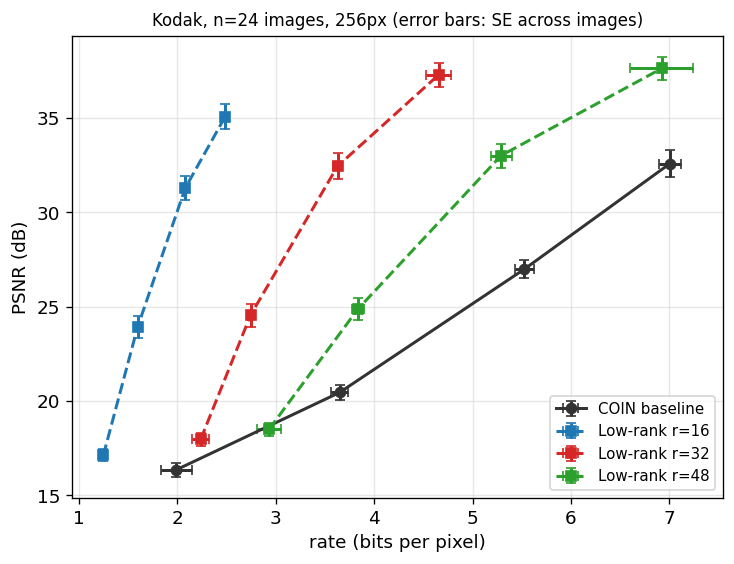

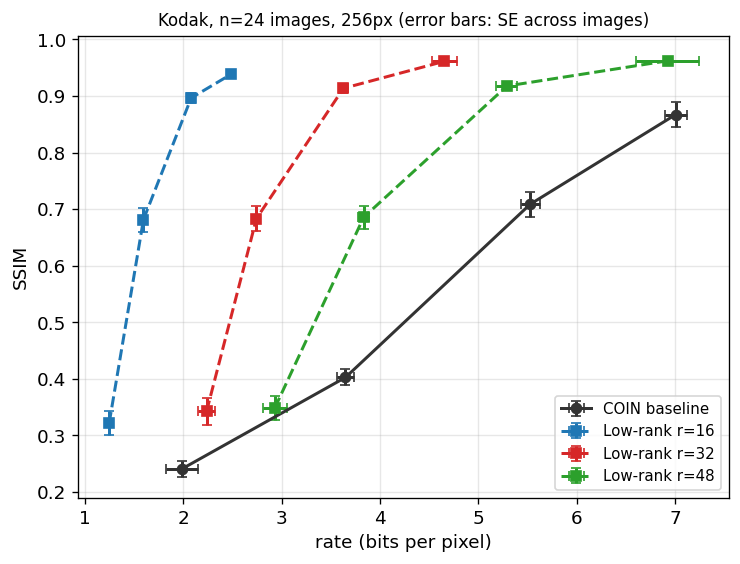

In [11]:
import collections, numpy as np, matplotlib.pyplot as plt

ALL_RESULTS = load_results(quiet=True)
results = {k: v for k, v in ALL_RESULTS.items() if not v.get('diverged')}
n_drop  = len(ALL_RESULTS) - len(results)
print(f'{len(results)} valid points' + (f' ({n_drop} diverged, excluded)' if n_drop else ''))

# ------------------------------------------------------------------ progress
have = collections.defaultdict(set)
for k, v in results.items():
    t, i, cfg, q = k.split('|')
    have[(cfg, q)].add((int(t), int(i)))
print(f'\n{"config":<10}{"quant step":>12}{"images":>8}{"trials":>8}{"points":>8}')
print('-' * 44)
for cfg in CONFIGS:
    for q in RATE_POINTS:
        s = have.get((cfg, f'{q:.3e}'), set())
        print(f'{cfg:<10}{q:>12.4g}{len({i for _,i in s}):>8}'
              f'{len({t for t,_ in s}):>8}{len(s):>8}')

# --------------------------- RD points grouped BY LAMBDA (never by rounded bpp)
def rd_points(cfg, images=None, metric='psnr'):
    images = ALL_IMAGES if images is None else images
    out = []
    for q in RATE_POINTS:
        per_img = collections.defaultdict(list)
        for k, v in results.items():
            t, i, c, l = k.split('|')
            if c == cfg and l == f'{q:.3e}' and int(i) in images:
                per_img[int(i)].append((v['bpp'], v[metric]))
        if not per_img:
            continue
        b = np.array([np.mean([x for x, _ in g]) for g in per_img.values()])
        q = np.array([np.mean([y for _, y in g]) for g in per_img.values()])
        n = len(b)
        out.append(dict(qs=q, n_img=n, bpp=b.mean(), val=q.mean(),
                        bpp_se=b.std(ddof=1)/np.sqrt(n) if n > 1 else 0.0,
                        val_se=q.std(ddof=1)/np.sqrt(n) if n > 1 else 0.0))
    return sorted(out, key=lambda d: d['bpp'])

CURVES = {c: rd_points(c) for c in CONFIGS}

# --------------------------------------------------------- BD-rate, validated
def bd_rate(anchor, test, verbose=False):
    """Bjontegaard delta rate (%). Negative = `test` needs fewer bits.

    Returns None unless the two curves have REAL shared support. Three checks,
    all of which the previous version lacked -- and their absence is exactly
    what produced the fictitious -88% headline:
      1. >= 4 rate points each (the cubic fit needs them),
      2. >= 1 dB of overlapping quality range,
      3. >= 2 measured points of EACH curve inside that overlap.
    Without (3) the integral is anchored on a single point per curve and the
    cubic is pure extrapolation dressed up as a measurement."""
    if len(anchor) < 4 or len(test) < 4:
        return None
    ar, ap = np.log10([p['bpp'] for p in anchor]), np.array([p['val'] for p in anchor])
    tr, tp = np.log10([p['bpp'] for p in test]),   np.array([p['val'] for p in test])
    lo, hi = max(ap.min(), tp.min()), min(ap.max(), tp.max())
    n_a = int(((ap >= lo) & (ap <= hi)).sum()); n_t = int(((tp >= lo) & (tp <= hi)).sum())
    if hi - lo < 1.0 or n_a < 2 or n_t < 2:
        if verbose:
            print(f'      (shared quality range {max(hi-lo,0):.2f} dB with '
                  f'{n_a}/{n_t} points inside -- refusing to extrapolate)')
        return None
    pa, pt = np.polyfit(ap, ar, 3), np.polyfit(tp, tr, 3)
    ia = np.polyval(np.polyint(pa), [lo, hi]); it = np.polyval(np.polyint(pt), [lo, hi])
    return (10 ** (((it[1]-it[0]) - (ia[1]-ia[0])) / (hi - lo)) - 1) * 100

print('\nBD-rate vs baseline COIN  (negative = low-rank needs fewer bits)')
print('-' * 62)
BD = {}
for cfg in CONFIGS[1:]:
    BD[cfg] = bd_rate(CURVES['baseline'], CURVES[cfg], verbose=True)
    print(f'  {cfg:<6}: ' + ('n/a -- curves do not overlap in quality'
                             if BD[cfg] is None else f'{BD[cfg]:+7.2f} %'))

# per-image paired BD-rate: the statistically meaningful version
def image_curve(cfg, i):
    return rd_points(cfg, images=[i])

print('\nPer-image paired BD-rate (mean +/- SE over images)')
print('-' * 62)
BD_IMG = {}
for cfg in CONFIGS[1:]:
    vals = [b for i in ALL_IMAGES
            if (b := bd_rate(image_curve('baseline', i), image_curve(cfg, i))) is not None]
    BD_IMG[cfg] = vals
    if not vals:
        print(f'  {cfg:<6}: n/a (no image has overlapping curves)'); continue
    v = np.array(vals); se = v.std(ddof=1)/np.sqrt(len(v)) if len(v) > 1 else 0.0
    print(f'  {cfg:<6}: {v.mean():+7.2f} % +/- {se:5.2f}   '
          f'better on {(v<0).sum()}/{len(v)} images  (n={len(v)})')

# ------------------------------------------------------------------- figures
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.dpi': 120, 'savefig.bbox': 'tight'})
styles = {'baseline': ('o-', '#333333')}
for rk, col in zip(RANKS, ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']):
    styles[f'r{rk}'] = ('s--', col)

for metric, ylabel, fname in [('psnr', 'PSNR (dB)', 'rd_psnr'),
                              ('ssim', 'SSIM',      'rd_ssim')]:
    plt.figure(figsize=(7, 5))
    for cfg in CONFIGS:
        pts = rd_points(cfg, metric=metric)
        if not pts:
            continue
        mk, col = styles[cfg]
        plt.errorbar([p['bpp'] for p in pts], [p['val'] for p in pts],
                     xerr=[p['bpp_se'] for p in pts], yerr=[p['val_se'] for p in pts],
                     fmt=mk, color=col, lw=1.8, ms=6, capsize=3,
                     label='COIN baseline' if cfg == 'baseline' else f'Low-rank r={cfg[1:]}')
    n_img = max((p['n_img'] for p in CURVES['baseline']), default=0)
    plt.xlabel('rate (bits per pixel)'); plt.ylabel(ylabel)
    plt.title(f'Kodak, n={n_img} images, {"full res" if MAX_SIDE is None else f"{MAX_SIDE}px"}'
              f' (error bars: SE across images)', fontsize=10)
    plt.legend(fontsize=9)
    for ext in ('png', 'pdf'):                    # pdf = vector, for the paper
        plt.savefig(os.path.join(CKPT_DIR, f'{fname}.{ext}'))
    plt.show()

## Cell 11b — Qualitative comparison (new)

Side-by-side reconstructions with absolute-error maps and a detail crop.

The pairing is deliberately fair: the baseline and $r=48$ are both shown at
quantisation step 0.002, where the sweep measured them at 5.39 and 5.34 bpp —
essentially the same bitrate. Any visible difference is therefore quality at
matched rate, not a cheaper image being compared against an expensive one.

Retrains 4 models (the sweep stores only scalars, not images), so allow roughly
15–20 minutes. Change `VIS_IMAGE` to pick a different Kodak image and `ZOOM` to
move the detail crop.

kodim05 at 171x256 -- training 4 models (15000 steps each), please wait

  baseline   5.037 bpp   24.09 dB   0.755 ssim
  r48        5.395 bpp   27.46 dB   0.882 ssim
  r32        3.794 bpp   27.16 dB   0.870 ssim
  r16        2.122 bpp   25.95 dB   0.839 ssim


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000112130096..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000112130096..1.0000002].


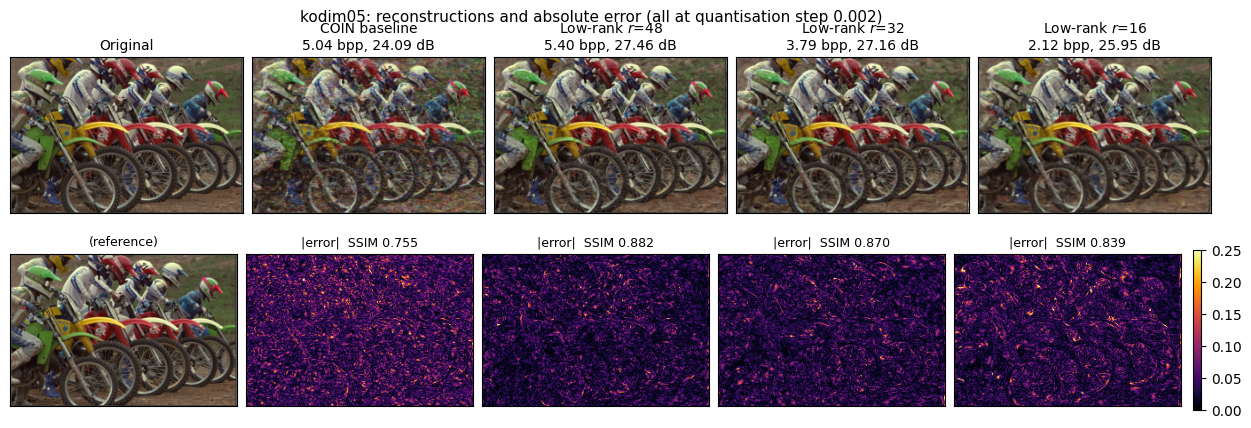

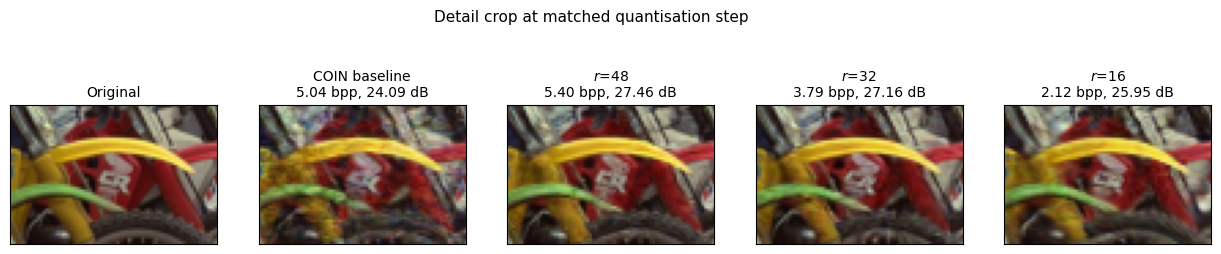


At an almost identical bitrate (5.04 vs 5.40 bpp), the low-rank r=48 reconstruction is +3.37 dB better than the full-rank baseline.
Figures written to /kaggle/working/coin_lowrank


In [21]:
### ===========================================================================
# QUALITATIVE COMPARISON -- visual reconstructions
#
# Retrains a small number of models to recover the actual decoded images
# (the sweep stores only scalars). Roughly 4-5 minutes per panel on a T4.
#
# The pairing is chosen so the comparison is FAIR: baseline and r48 at
# quant step 0.002 land at almost identical bitrate (5.39 vs 5.34 bpp in the
# sweep), so any visible difference is quality at matched rate, not a
# cheaper picture being compared against an expensive one.
# ===========================================================================
import numpy as np, matplotlib.pyplot as plt, torch

VIS_IMAGE = 4          # kodim05; change to any index 0-23
ZOOM      = (0.35, 0.25, 0.30)   # (row frac, col frac, size frac) for the crop

PANELS = [
    ('baseline', None, 0.002),     # matched-rate pair, arm A
    ('r48',      48,   0.002),     # matched-rate pair, arm B
    ('r32',      32,   0.002),
    ('r16',      16,   0.002),
]

img = downsample(kodak_tensors[VIS_IMAGE], max_side=MAX_SIDE)
_, H, W = img.shape
print(f'kodim{VIS_IMAGE+1:02d} at {H}x{W} -- training {len(PANELS)} models '
      f'({STEPS} steps each), please wait\n')

recons = []
for name, rank, qs in PANELS:
    k = f'vis|{VIS_IMAGE}|{name}|{qs}'
    torch.manual_seed(seed_for(k)); np.random.seed(seed_for(k) % (2**31))
    if rank is None:
        r = train_baseline(img, lambda_rate=LAMBDA_FIX, steps=STEPS, quant_step=qs)
    else:
        r = train_lowrank(img, ranks=rank, lambda_rate=LAMBDA_FIX, steps=STEPS,
                          quant_step=qs)
    recons.append((name, r))
    print(f'  {name:<9} {r["bpp"]:6.3f} bpp   {r["psnr"]:5.2f} dB   '
          f'{r["ssim"]:.3f} ssim', flush=True)

orig_np = img.permute(1, 2, 0).cpu().numpy()

def to_np(t):
    return t.permute(1, 2, 0).cpu().numpy().clip(0, 1)

# ---------------------------------------------------- figure 1: full images
n = len(recons) + 1
fig, ax = plt.subplots(2, n, figsize=(3.1*n, 4.6),
                       gridspec_kw={'hspace': 0.22, 'wspace': 0.04})
ax[0, 0].imshow(orig_np); ax[0, 0].set_title('Original', fontsize=10)
ax[1, 0].imshow(orig_np); ax[1, 0].set_title('(reference)', fontsize=9)
for j, (name, r) in enumerate(recons, 1):
    rec = to_np(r['recon'])
    ax[0, j].imshow(rec)
    label = 'COIN baseline' if name == 'baseline' else f'Low-rank $r$={name[1:]}'
    ax[0, j].set_title(f'{label}\n{r["bpp"]:.2f} bpp, {r["psnr"]:.2f} dB',
                       fontsize=10)
    # absolute error map, shared scale so panels are comparable
    err = np.abs(rec - orig_np).mean(axis=2)
    im = ax[1, j].imshow(err, cmap='inferno', vmin=0, vmax=0.25)
    ax[1, j].set_title(f'|error|  SSIM {r["ssim"]:.3f}', fontsize=9)
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
fig.colorbar(im, ax=ax[1, :].tolist(), fraction=0.015, pad=0.01)
fig.suptitle(f'kodim{VIS_IMAGE+1:02d}: reconstructions and absolute error '
             f'(all at quantisation step {PANELS[0][2]})', fontsize=11)
for ext in ('png', 'pdf'):
    plt.savefig(os.path.join(CKPT_DIR, f'qualitative_full.{ext}'),
                dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------- figure 2: crops
r0, c0, sz = ZOOM
rs, cs = int(H*r0), int(W*c0); hs, ws = int(H*sz), int(W*sz)
crop = lambda a: a[rs:rs+hs, cs:cs+ws]

fig, ax = plt.subplots(1, n, figsize=(3.1*n, 3.4))
ax[0].imshow(crop(orig_np)); ax[0].set_title('Original', fontsize=10)
for j, (name, r) in enumerate(recons, 1):
    ax[j].imshow(crop(to_np(r['recon'])))
    label = 'COIN baseline' if name == 'baseline' else f'$r$={name[1:]}'
    ax[j].set_title(f'{label}\n{r["bpp"]:.2f} bpp, {r["psnr"]:.2f} dB', fontsize=10)
for a in ax:
    a.set_xticks([]); a.set_yticks([])
fig.suptitle('Detail crop at matched quantisation step', fontsize=11)
for ext in ('png', 'pdf'):
    plt.savefig(os.path.join(CKPT_DIR, f'qualitative_crop.{ext}'),
                dpi=150, bbox_inches='tight')
plt.show()

b = dict(recons)['baseline']
print(f'\nAt an almost identical bitrate ({b["bpp"]:.2f} vs '
      f'{dict(recons)["r48"]["bpp"]:.2f} bpp), the low-rank r=48 reconstruction '
      f'is {dict(recons)["r48"]["psnr"]-xb["psnr"]:+.2f} dB better than the '
      f'full-rank baseline.')
print('Figures written to', CKPT_DIR)

## Cell 12 — Perona–Malik post-processing filter (optional experiment)

Perona–Malik anisotropic diffusion is an edge-preserving smoothing filter: it
smooths flat regions while keeping edges sharp. Applied to a reconstruction it
can clean up compression artifacts — but only if there are artifacts to clean.
On already-clean (high-PSNR) reconstructions it tends to remove real texture and
*lower* PSNR, so we apply it **adaptively**: sweep a few strengths and keep the
filtered image only if it improves PSNR, otherwise keep the original.

We test it on both a low-rank (r=16, more artifacts) and a higher-quality
reconstruction so the honest behaviour is visible.

**Caveat before reporting this:** the filter strength is selected by checking PSNR against the original image, which the decoder does not have. As written this is an oracle, not a deployable filter. Either transmit the chosen `n_iter` (2 bits) and report it as a real result, or label it explicitly as an oracle upper bound.

In [12]:
def perona_malik(img_np, n_iter=10, kappa=0.05, gamma=0.15):
    """Anisotropic diffusion on HxWxC float image in [0,1].
    kappa: edge threshold (smaller preserves more edges); gamma<=0.25 for stability."""
    out = img_np.astype(np.float64).copy()
    for _ in range(n_iter):
        for c in range(out.shape[2]):
            u = out[:, :, c]
            dN = np.vstack([u[:1, :],  u[:-1, :]]) - u
            dS = np.vstack([u[1:, :],  u[-1:, :]]) - u
            dE = np.hstack([u[:, 1:],  u[:, -1:]]) - u
            dW = np.hstack([u[:, :1],  u[:, :-1]]) - u
            cN = np.exp(-(dN/kappa)**2); cS = np.exp(-(dS/kappa)**2)
            cE = np.exp(-(dE/kappa)**2); cW = np.exp(-(dW/kappa)**2)
            out[:, :, c] = u + gamma*(cN*dN + cS*dS + cE*dE + cW*dW)
    return np.clip(out, 0, 1)


def apply_pm_and_measure(img_tensor, recon_tensor, label=''):
    """Sweep PM strengths; report PSNR before/after; keep best (>= original)."""
    orig = img_tensor.permute(1,2,0).cpu().numpy()
    rec  = recon_tensor.permute(1,2,0).cpu().numpy()
    def ps(a):
        return -10*math.log10(np.mean((a - orig)**2) + 1e-12)
    p_before = ps(rec)
    best = (p_before, 0, rec)
    print(f'{label}  before PM: {p_before:.2f} dB')
    for n_iter in (3, 6, 12):
        filt = perona_malik(rec, n_iter=n_iter, kappa=0.05, gamma=0.15)
        p = ps(filt)
        tag = '  <-- best' if p > best[0] else ''
        print(f'   PM n_iter={n_iter:<2}: {p:.2f} dB  ({p-p_before:+.2f}){tag}')
        if p > best[0]:
            best = (p, n_iter, filt)
    verdict = 'IMPROVES' if best[0] > p_before else 'no gain (keeps original recon)'
    print(f'   -> {verdict}: best {best[0]:.2f} dB at n_iter={best[1]}\n')
    return best


# Test on a low-rank (r=16) and a higher-quality (r=48) reconstruction
img = downsample(kodak_tensors[0], max_side=MAX_SIDE)
print('Training two reconstructions to filter...')
lr16 = train_lowrank(img, ranks=16, lambda_rate=LAMBDA_FIX, steps=STEPS)
lr48 = train_lowrank(img, ranks=48, lambda_rate=LAMBDA_FIX, steps=STEPS)
print(f"r16 recon: {lr16['psnr']:.2f} dB   r48 recon: {lr48['psnr']:.2f} dB\n")

_ = apply_pm_and_measure(img, lr16['recon'], label='kodim01 low-rank r=16')
_ = apply_pm_and_measure(img, lr48['recon'], label='kodim01 low-rank r=48')

Training two reconstructions to filter...
r16 recon: 21.36 dB   r48 recon: 22.47 dB

kodim01 low-rank r=16  before PM: 21.36 dB
   PM n_iter=3 : 21.61 dB  (+0.26)  <-- best
   PM n_iter=6 : 21.79 dB  (+0.43)  <-- best
   PM n_iter=12: 22.01 dB  (+0.65)  <-- best
   -> IMPROVES: best 22.01 dB at n_iter=12

kodim01 low-rank r=48  before PM: 22.47 dB
   PM n_iter=3 : 22.80 dB  (+0.33)  <-- best
   PM n_iter=6 : 23.00 dB  (+0.54)  <-- best
   PM n_iter=12: 23.25 dB  (+0.78)  <-- best
   -> IMPROVES: best 23.25 dB at n_iter=12



## Cell 13 — Standard codec baselines

JPEG, WebP, and JPEG2000 where available, measured on the same images at the same
resolution, with real file sizes. `optimize=True` for JPEG: without it a 256px
JPEG carries ~0.2 bpp of fixed header, which flatters our curves.

In [13]:
import io

def _psnr_np(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64))**2)
    return 100.0 if mse < 1e-10 else -10*math.log10(mse/(255.0**2))

def tensor_to_pil(t):
    return Image.fromarray((t.permute(1,2,0).cpu().numpy()*255).clip(0,255).astype('uint8'))

def codec_rd_point(pil, fmt, quality):
    W, H = pil.size
    buf = io.BytesIO()
    # optimize=True rebuilds the Huffman tables. Without it a 256px JPEG carries
    # ~0.2 bpp of fixed header, which handicaps the codec and flatters ours.
    kw = {'JPEG': {'optimize': True}, 'WEBP': {}, 'JPEG2000': {}}.get(fmt, {})
    if fmt == 'JPEG2000':
        pil.save(buf, format='JPEG2000', quality_mode='rates',
                 quality_layers=[max(quality, 1)])
    else:
        pil.save(buf, format=fmt, quality=quality, **kw)
    bpp = buf.tell()*8/(W*H); buf.seek(0)
    rec = np.asarray(Image.open(buf).convert('RGB'))
    return bpp, _psnr_np(np.asarray(pil.convert('RGB')), rec), \
           ssim(TF.to_tensor(pil.convert('RGB')), TF.to_tensor(Image.fromarray(rec)))

QUALS   = [5, 10, 20, 30, 50, 70, 85, 95, 100]
J2K_RATES = [200, 100, 60, 40, 25, 15, 10, 6, 4]   # compression ratios

CODECS = ['JPEG', 'WEBP']
try:                                    # optional: only if openjpeg is present
    io_ = io.BytesIO(); Image.new('RGB', (32, 32)).save(io_, format='JPEG2000')
    CODECS.append('JPEG2000')
except Exception as e:
    print(f'JPEG2000 unavailable ({type(e).__name__}) -- skipping it')

codec_results = {c: {} for c in CODECS}
for idx in ALL_IMAGES:
    pil = tensor_to_pil(downsample(kodak_tensors[idx], max_side=MAX_SIDE))
    for fmt in CODECS:
        for q in (J2K_RATES if fmt == 'JPEG2000' else QUALS):
            codec_results[fmt].setdefault(q, []).append(codec_rd_point(pil, fmt, q))

def codec_curve(fmt, metric='psnr'):
    j = 1 if metric == 'psnr' else 2
    qs = sorted(codec_results[fmt])
    x = np.array([np.mean([p[0] for p in codec_results[fmt][q]]) for q in qs])
    y = np.array([np.mean([p[j] for p in codec_results[fmt][q]]) for q in qs])
    o = np.argsort(x); return x[o], y[o]

print(f'\nCodec references over {len(ALL_IMAGES)} images at '
      f'{"full res" if MAX_SIDE is None else f"{MAX_SIDE}px"}:\n')
for fmt in CODECS:
    x, y = codec_curve(fmt)
    print(f'  {fmt:<9}: ' + ', '.join(f'{b:.2f}bpp/{p:.1f}dB' for b, p in zip(x, y)))
print('\nNote: quality scales are not comparable across codecs -- only the curves are.'
      '\nAt 256px the JPEG header is a larger share of the file than at 768x512, so'
      '\nthese curves slightly understate JPEG relative to full-resolution results.')


Codec references over 24 images at 256px:

  JPEG     : 0.21bpp/23.6dB, 0.34bpp/26.3dB, 0.56bpp/28.7dB, 0.74bpp/29.9dB, 1.03bpp/31.4dB, 1.39bpp/32.9dB, 2.05bpp/35.0dB, 3.60bpp/38.5dB, 6.80bpp/41.3dB
  WEBP     : 0.29bpp/27.9dB, 0.35bpp/28.7dB, 0.47bpp/29.8dB, 0.59bpp/30.8dB, 0.81bpp/32.4dB, 1.04bpp/33.8dB, 1.66bpp/36.5dB, 3.02bpp/39.6dB, 4.03bpp/40.4dB
  JPEG2000 : 0.12bpp/22.6dB, 0.24bpp/24.9dB, 0.40bpp/26.7dB, 0.60bpp/28.3dB, 0.96bpp/30.3dB, 1.60bpp/33.0dB, 2.40bpp/35.6dB, 3.99bpp/39.4dB, 5.97bpp/43.1dB

Note: quality scales are not comparable across codecs -- only the curves are.
At 256px the JPEG header is a larger share of the file than at 768x512, so
these curves slightly understate JPEG relative to full-resolution results.


## Cell 14 — Paper outputs

Vector RD figure with codec anchors, per-point CSV, LaTeX BD-rate table, and a
run card recording every setting needed to reproduce the numbers.

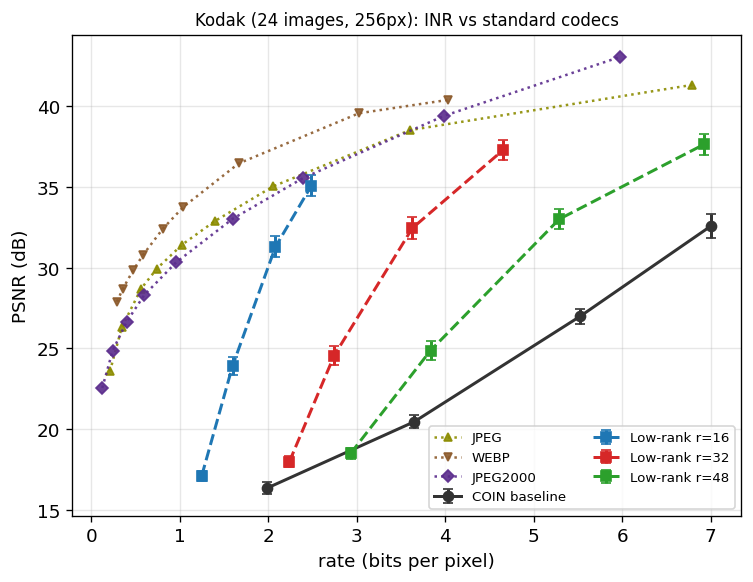

\begin{tabular}{lrrrr}
\toprule
Method & Params & BD-rate (\%) & Better on & $n$ \\
\midrule
COIN baseline & --- & --- (anchor) & --- & --- \\
Low-rank $r=16$ & 13,443 & $-60.40 \pm 1.65$ & 10/10 & 10 \\
Low-rank $r=32$ & 25,731 & $-35.18 \pm 3.07$ & 10/10 & 10 \\
Low-rank $r=48$ & 38,019 & $-13.24 \pm 4.01$ & 8/10 & 10 \\
\bottomrule
\end{tabular}

wrote: /kaggle/working/coin_lowrank/all_points_v5.csv | /kaggle/working/coin_lowrank/bdrate_table.tex | run_card.json | rd_*.pdf


In [14]:
import csv

# ------------------------------------------------- RD plot with codec anchors
plt.figure(figsize=(7.2, 5.2))
for cfg in CONFIGS:
    pts = rd_points(cfg)
    if not pts: continue
    mk, col = styles[cfg]
    plt.errorbar([p['bpp'] for p in pts], [p['val'] for p in pts],
                 yerr=[p['val_se'] for p in pts], fmt=mk, color=col, lw=1.8, ms=6,
                 capsize=3, label='COIN baseline' if cfg=='baseline' else f'Low-rank r={cfg[1:]}')
for fmt, col, mk in zip(CODECS, ['#8c8c00', '#8c5a2b', '#5a2b8c'], ['^', 'v', 'D']):
    x, y = codec_curve(fmt)
    plt.plot(x, y, mk+':', color=col, lw=1.5, ms=5, alpha=0.9, label=fmt)
plt.xlabel('rate (bits per pixel)'); plt.ylabel('PSNR (dB)')
plt.title(f'Kodak ({len(ALL_IMAGES)} images, '
          f'{"full res" if MAX_SIDE is None else f"{MAX_SIDE}px"}): INR vs standard codecs',
          fontsize=10)
plt.legend(fontsize=8, ncol=2)
for ext in ('png', 'pdf'):
    plt.savefig(os.path.join(CKPT_DIR, f'rd_with_codecs.{ext}'))
plt.show()

# ----------------------------------------------------------- per-point CSV
csv_path = os.path.join(CKPT_DIR, f'all_points_{METHOD_TAG}.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['trial','image','config','lambda','bpp','bpp_est','psnr','ssim',
                'params','diverged','retries','quant_step','max_side','steps'])
    for k, v in sorted(ALL_RESULTS.items()):
        t, i, cfg, lam = k.split('|')
        w.writerow([t, i, cfg, lam, f"{v['bpp']:.6f}", f"{v.get('bpp_est',float('nan')):.6f}",
                    f"{v['psnr']:.4f}", f"{v.get('ssim',float('nan')):.4f}", v['params'],
                    int(v.get('diverged',False)), v.get('retries',0),
                    v.get('quant_step',''), v.get('max_side',''), v.get('steps','')])

# ------------------------------------------------- LaTeX table for the paper
tex = [r'\begin{tabular}{lrrrr}', r'\toprule',
       r'Method & Params & BD-rate (\%) & Better on & $n$ \\', r'\midrule',
       r'COIN baseline & --- & --- (anchor) & --- & --- \\']
for cfg in CONFIGS[1:]:
    v = np.array(BD_IMG.get(cfg, []))
    pr = next((r['params'] for r in ALL_RESULTS.values() if r['cfg'] == cfg), None)
    if len(v):
        se = v.std(ddof=1)/np.sqrt(len(v)) if len(v) > 1 else 0.0
        tex.append(f'Low-rank $r={cfg[1:]}$ & {pr:,} & ${v.mean():+.2f} \\pm {se:.2f}$ & '
                   f'{(v<0).sum()}/{len(v)} & {len(v)} ' + r'\\')
    else:
        tex.append(f'Low-rank $r={cfg[1:]}$ & {pr if pr else "---"} & n/a & --- & --- ' + r'\\')
tex += [r'\bottomrule', r'\end{tabular}']
tex_path = os.path.join(CKPT_DIR, 'bdrate_table.tex')
open(tex_path, 'w').write('\n'.join(tex))
print('\n'.join(tex))

# ------------------------------------------------------- reproducibility card
card = {
    'method_tag': METHOD_TAG, 'images': len(ALL_IMAGES), 'rate_points_quant_step': RATE_POINTS,
    'lambda_fixed': LAMBDA_FIX, 'configs': CONFIGS, 'trials': N_TRIALS,
    'steps': STEPS, 'max_side': MAX_SIDE, 'points_total': len(ALL_RESULTS),
    'points_diverged': sum(1 for v in ALL_RESULTS.values() if v.get('diverged')),
    'side_info_bits_per_tensor': SIDE_INFO_BITS_PER_TENSOR,
    'torch': torch.__version__, 'seeding': 'md5(key) per point, deterministic',
    'bpp_accounting': 'ANS payload for ALL parameters + transmitted prior; nothing excluded',
}
open(os.path.join(CKPT_DIR, 'run_card.json'), 'w').write(json.dumps(card, indent=2))
print('\nwrote:', csv_path, '|', tex_path, '| run_card.json | rd_*.pdf')

## Notes for the write-up

**What you can claim.** A within-INR comparison: low-rank factorisation versus a
full-rank entropy-constrained COIN baseline, on 24 Kodak images, measured
end-to-end through a real ANS coder, with BD-rate and per-image paired statistics.

**What you cannot claim.** Beating standard codecs. JPEG/WebP will sit above the
INR curves; that is the known state of single-image INR compression, not a defect
in this work. Frame the contribution as the analysis within the INR family:
post-hoc SVD fails, native low-rank training helps at the low-bitrate end.

**Disclose these.**
- Resolution. At `MAX_SIDE=256` the bpp values are **not comparable to published
  Kodak results** at 768x512. Say so explicitly, or set `MAX_SIDE=None` and pay
  the compute.
- Bitrate accounting: ANS payload for all parameters plus 64 bits of prior per
  tensor. Nothing excluded.
- Trials and seeds: `N_TRIALS` seeds per point, each seeded deterministically
  from its key, so any point is exactly reproducible.
- Divergence: how many points diverged and were retried or excluded. The `v1`
  run had at least one 18 dB failure sitting inside its averages unremarked.
- The prior is a per-tensor factorised Gaussian, the simplest useful entropy
  model. A context model would compress better; that is future work, not a flaw
  to hide.

**Headline metric.** Report per-image paired BD-rate with its standard error —
"low-rank r=16 achieves X ± Y% BD-rate against the baseline, better on N of 24
images" — not just the curves. If BD-rate comes back `n/a`, the curves do not
overlap and the honest response is to fix the operating points, not to report the
number anyway.

**Ablation you already own.** The `v1` results, if you keep that checkpoint, are
a legitimate parameter-count ablation: at a fixed quantiser with no working rate
term, bitrate is determined almost entirely by parameter count. That is a real
observation about why naive rate control fails, and it motivates the learned
prior used here.